# Bat Echolocation Feature Extraction
Goal: Extract features from bat echolocation calls, remove outliers, then average across all calls in a bat pass

Steps:
1. Input a file
2. Convert to frequency domain and vizualize
3. Apply filter to remove lower-frequency background noise below the bat calls
4. Convert back to time domain
5. Use voice activity detection (VAD) with energy cutoff to get the timestamps for the bat calls and inter-call intervals (ICIs)
6. For each call within the bat pass (excluding first and last which could be cut off), extract the following features:
    - start time
    - end time
    - call duration
    - time until the next call
    - min frequency
    - max frequency
    - frequency of most energy
    - slope estimate assuming downward shape
7. Show those results in a table, with each column being a feature, and each row being a call
8. Check for outliers on each feature and remove calls with outliers
9. Get averages for the features and prep for export

In [229]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore

## Helper Methods

In [4]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=sr, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [5]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that separates a group of sound
# Returns periods of time with voice activity separated by silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_voice_activity_timestamps(*, vad_output: List[int], frame_shift: int, min_silence_duration: int = 1000):
    min_silence_frames = int(min_silence_duration / frame_shift)

    groups = []
    start_idx = None
    silence_counter = 0

    for i, frame in enumerate(vad_output):
        if frame == 1:
            if start_idx is None:
                start_idx = i
            silence_counter = 0
        else:
            if start_idx is not None:
                silence_counter += 1
                if silence_counter >= min_silence_frames:
                    # Silence is long enough, so close the current voice group
                    end_idx = i - silence_counter
                    start_time = start_idx * frame_shift / 1000
                    end_time = (end_idx + 1) * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 4),
                        'end': round(end_time, 4)
                    })
                    start_idx = None
                    silence_counter = 0

    # Handle case where audio ends with voice activity
    if start_idx is not None:
        end_time = (len(vad_output)+1) * frame_shift / 1000
        groups.append({
            'start': round(start_idx * frame_shift / 1000, 4),
            'end': round(end_time, 4)
        })

    return groups

In [6]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that will be included
# Returns timestamps for silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_timestamps_silences(*, vad_output: List[int], frame_shift: int, min_silence_duration: int=1000):
    min_silence_frames = int(min_silence_duration / frame_shift)
    groups = []
    start_idx = None

    for i, frame in enumerate(vad_output):
        if frame==0:
            if start_idx is None:
                start_idx = i
        else:
            if start_idx is not None:
                end_idx = i
                duration = end_idx - start_idx

                if duration >= min_silence_frames:
                    start_time = start_idx * frame_shift / 1000
                    end_time = end_idx * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 2),
                        'end': round(end_time, 2)
                    })

                start_idx = None

    # Handle case where the last segment goes to the end
    if start_idx is not None:
        end_idx = len(vad_output)
        duration = end_idx - start_idx
        if duration >= min_silence_frames:
            start_time = start_idx * frame_shift / 1000
            end_time = end_idx * frame_shift / 1000
            groups.append({
                'start': round(start_time, 2),
                'end': round(end_time, 2)
            })

    return groups

In [7]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

In [23]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps, sr):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * sr) # convert start time into sample index
        end_sample = int(float(ts['end']) * sr)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [61]:
# Create method to easily plot spectrograms
def plot_spectrogram(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [62]:
# Create method to easily plot spectrograms AND zoom in on the x-axis
def plot_spectrogram_zoom(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000, xmin=0, xmax=12):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlim(xmin, xmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [153]:
# Function that takes in:
    #   stft_abs which comes from stft = librosa.stft() && stft_abs = np.abs(stft_bat) 
    #   and where filters for background noise have already been applied
    #   times, which comes from librosa.frames_to_time()
    #   the start and end times (in seconds) of the call
    #   an energy cutoff, for instance, what's the minimum energy that something has to have
    #   to be considered part of the sound
# Function returns the min frequency, the max frequency, and the frequency with most energy (Hz)
def extractMinMaxAndMostEnergyFrequencies(stft_abs, times, start_time, end_time, energy_cutoff):
    # slice time window for the first bat call
    time_mask = (times >= start_time) & (times <= end_time)
    stft_call = stft_abs[:, time_mask]
    
    # energy per frequency bin
    energy_per_freq = stft_call.mean(axis=1)

    # normalize
    energy_norm = energy_per_freq / energy_per_freq.max()

    # cutoff mask
    mask = energy_norm >= energy_cutoff

    # get results
    min_freq = bat_frequencies[mask].min()
    max_freq = bat_frequencies[mask].max()
    max_energy_freq = bat_frequencies[np.argmax(energy_per_freq)]

    # return results
    return {'min_freq': min_freq, 'max_freq': max_freq, 'max_energy_freq': max_energy_freq}

## File input

In [9]:
# Recordings done with dodotronic with sampling rate of 384,000
sr = 384000

In [10]:
filename = 'bat_20241020_1756.wav'

In [11]:
# Load audio with Librosa.load and sample at the correct rate
file, sr = librosa.load(filename, sr=sr)

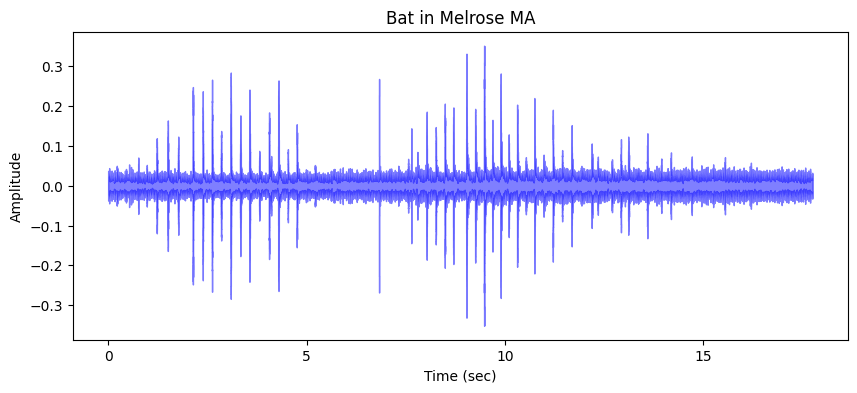

In [12]:
plotWaveform(file, 'Bat in Melrose MA')

## Frequency Domain and Spectrogram

In [52]:
# Based on previous work, found that 2048 samples per frame works best for ultrasound in the time/frequency tradeoff 
# where larger frame sizes give better frequency resolution but worse time resolution
# TODO - for better onset detection, could lower this number to prioritize time resolution
# Use power of 2 which works best with Discrete Fourier transform (e.g., 512, 1024, 2048, 4096, 8192)
FRAME_LENGTH_SPEC = 2048

In [54]:
HOP_LENGTH_SPEC = FRAME_LENGTH_SPEC//4

In [56]:
# Apply the Short-Time Fourier Transform to convert to the frequency domain
stft_bat = librosa.stft(file, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat.shape

(1025, 13321)

In [59]:
stft_bat_abs = np.abs(stft_bat) ** 2
stft_bat_dB = librosa.power_to_db(np.abs(stft_bat_abs), ref=np.max)

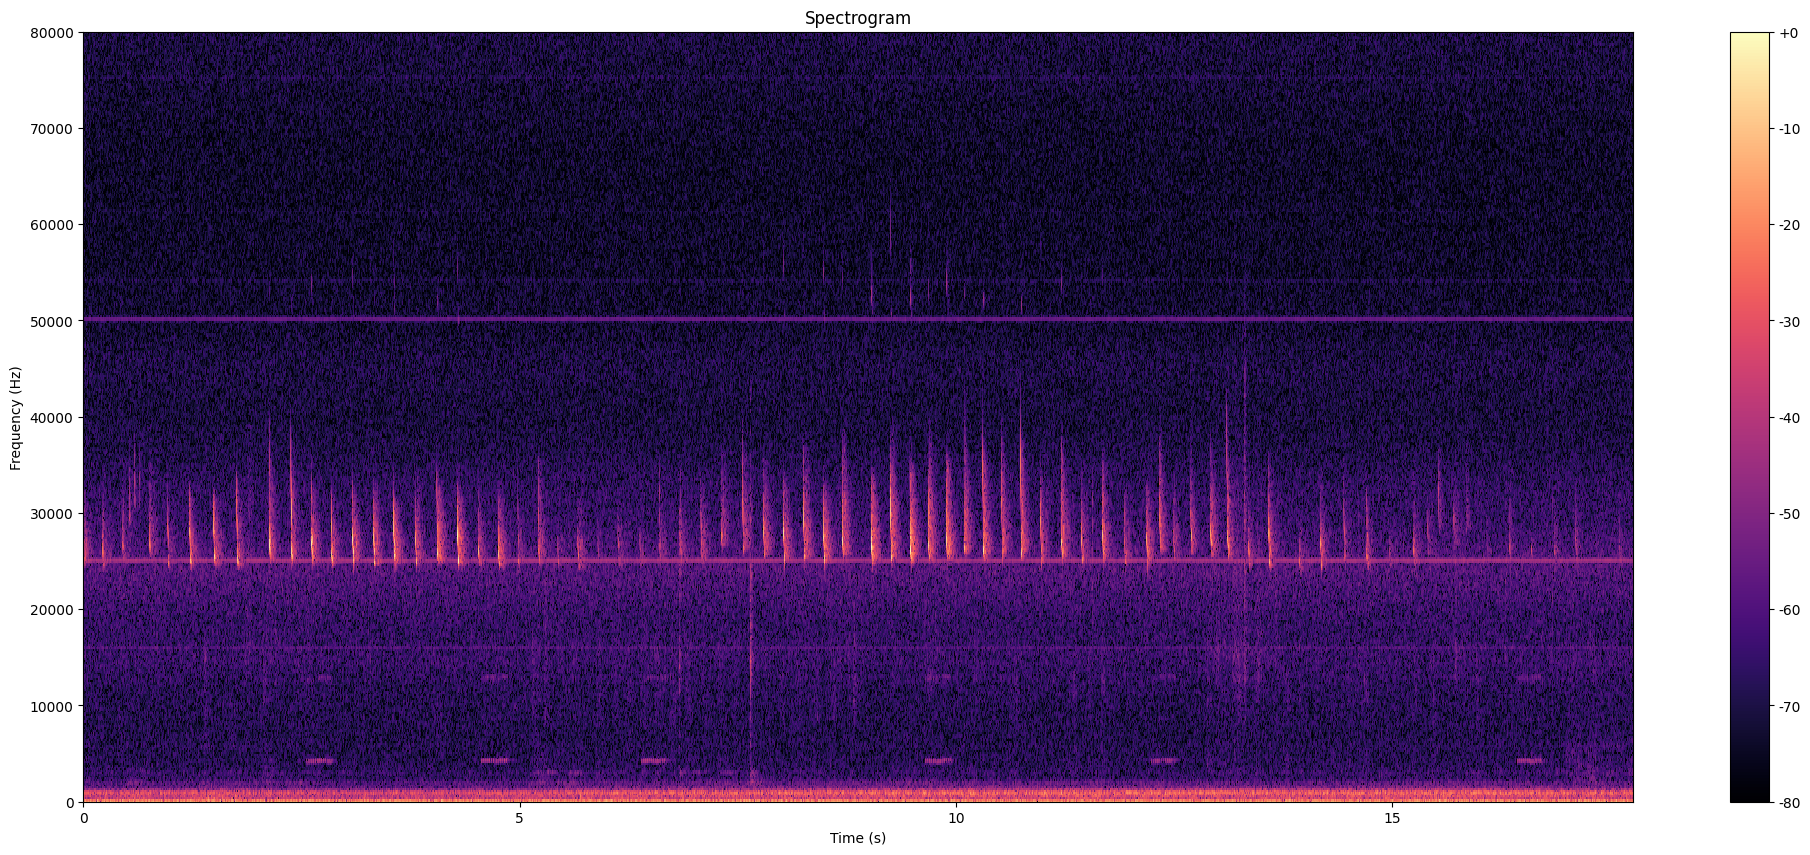

In [65]:
# Plot spectrogram
plot_spectrogram(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 0, 80000)

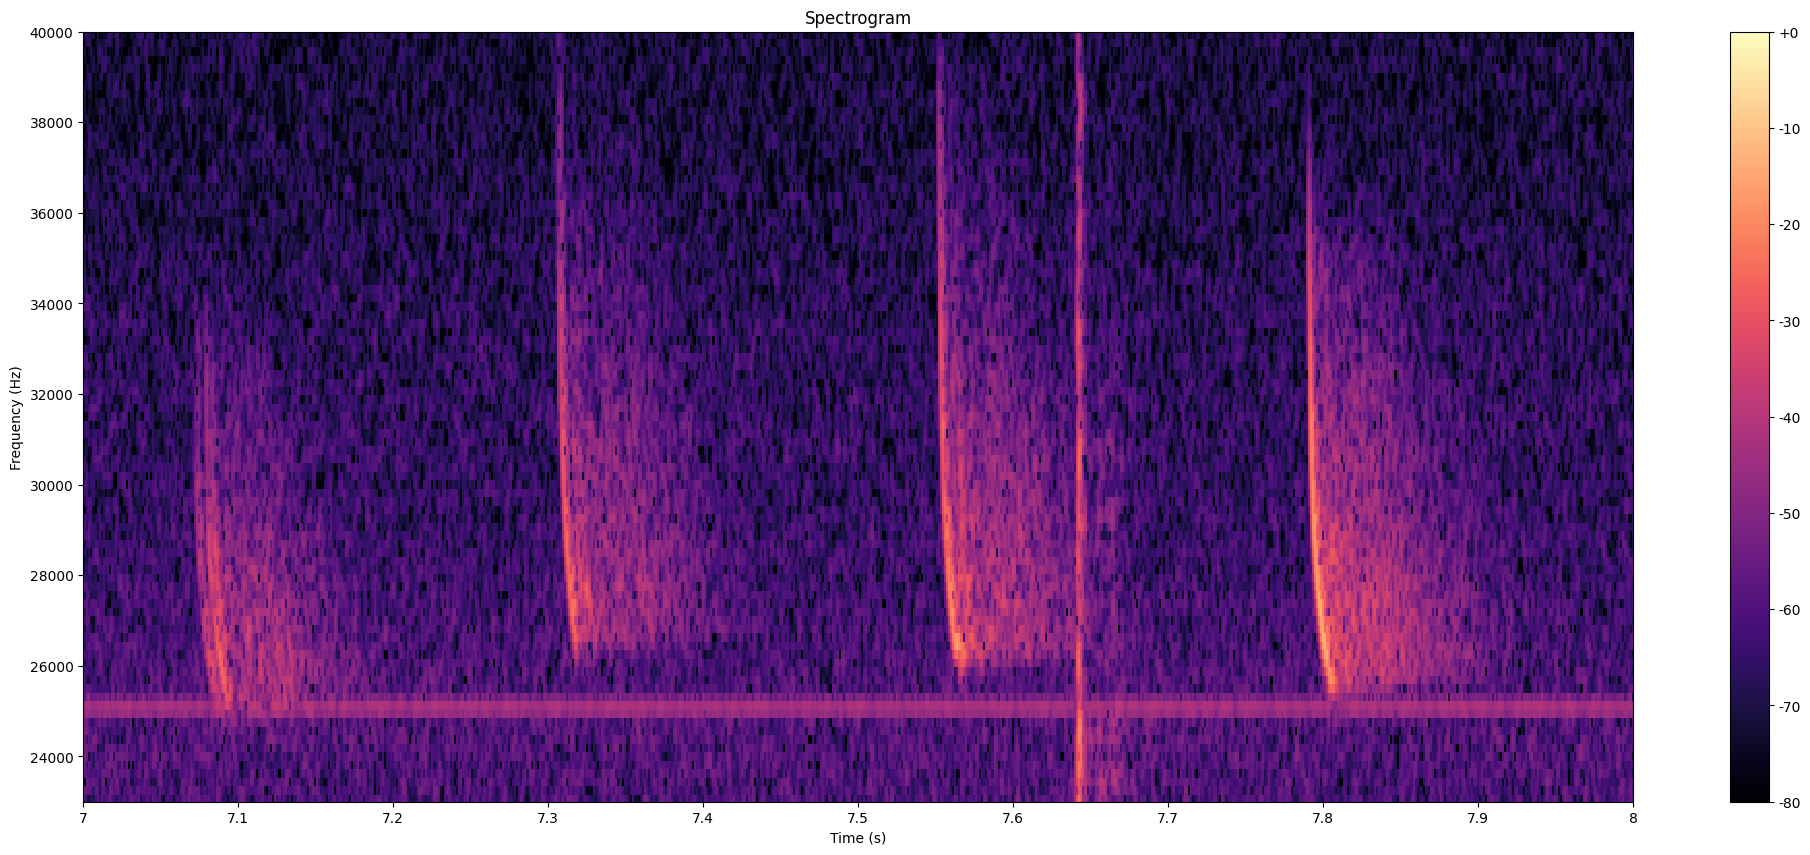

In [67]:
# Zoom in on highest frequencies and zoom in on time a bit to see more detail
plot_spectrogram_zoom(stft_bat_dB, sr, HOP_LENGTH_SPEC, "linear", 23000, 40000, 7, 8)

## Filter out lower frequency background noise

In [68]:
# All bat energy is above 20,000 Hz, but there is also background noise at much lower frequencies
# Apply a cutoff, and zero out all the values below 25,000 Hz to isolate the bat sounds
CUTOFF = 20000

In [69]:
# Get the frequency values corresponding to the rows of the STFT
bat_frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH_SPEC)
bat_frequencies

array([0.000000e+00, 1.875000e+02, 3.750000e+02, ..., 1.916250e+05,
       1.918125e+05, 1.920000e+05])

In [70]:
# Find the index of the frequency closest to the cutoff
cutoff_idx = np.argmax(bat_frequencies >= CUTOFF)
cutoff_idx

np.int64(107)

In [71]:
# Create a copy of the STFT matrix
stft_bat_filtered = stft_bat.copy()

In [72]:
# Zero out frequencies below cutoff
stft_bat_filtered[:cutoff_idx, :] = 0

In [73]:
# Remove complex numbers, retain just amplitude, and choose between amplitude or power spectrograms
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2 # use for a power spectrogram

In [74]:
# Transform amplitude OR power from linear to log scale decibels to improve visualization
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

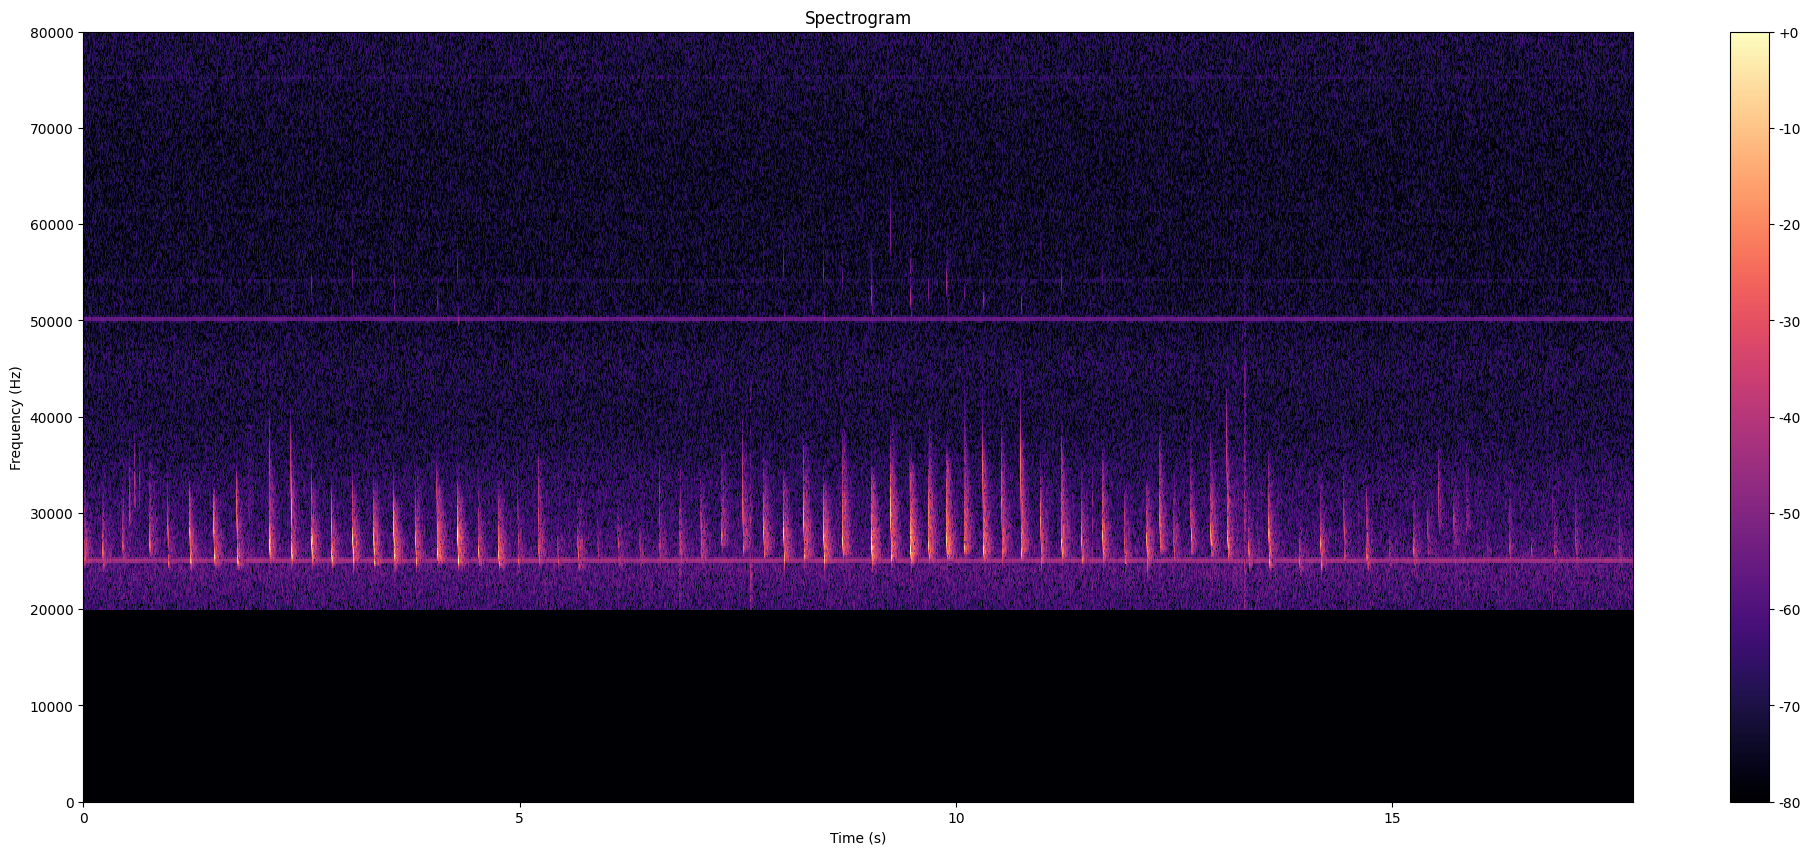

In [76]:
# Plot spectrogram for bats with lower frequency sounds filtered out
plot_spectrogram(stft_bat_filtered_dB, sr, HOP_LENGTH_SPEC, "linear", 0, 80000)

In [78]:
# Convert back to the time domain using the inverse STFT
bat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)

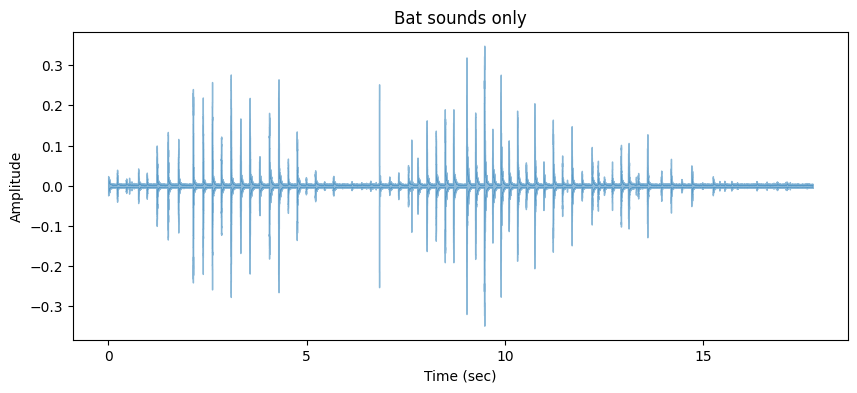

In [80]:
# Plot the waveform of bats without background noise
plt.figure(figsize=(10, 4))
librosa.display.waveshow(bat_filtered, sr=sr, alpha=0.5)
plt.title("Bat sounds only")
plt.xlabel("Time (sec)") 
plt.ylabel("Amplitude")
plt.show()

## Using VAD to extract timestamps for individual calls

In [82]:
FRAME_LENGTH = 10 # milliseconds, normally 25 would be used for longer sounds but bat calls are so short

In [83]:
FRAME_SHIFT = 5 # milliseconds

In [84]:
# Generally a silence longer than 90ms is should separate one search call from another
MIN_ICI = 90 # in milliseconds
# TODO - manipulate to detect feeding buzzes and strobe groups

In [85]:
# call might be 19ms (3-50ms) or 0.5ms for micro-calls, while a ICI might be like 228ms
# Search phase ICI's are ~100 ms or longer
# Approach phase ICI's are ~20 ms
# Feeding buzz ICI's are ~9-18 ms


In [86]:
# Initialize VAD and get the output, which is an array of 0's and 1's, where 0 = frame with silence
# and 1 = frame with voice activity above the energy threshold
vad = EnergyVAD(frame_length=FRAME_LENGTH, frame_shift=FRAME_SHIFT, sample_rate=sr, energy_threshold=0.04)

In [87]:
vad_output = vad(bat_filtered)

In [88]:
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
calls

[{'start': 0.0, 'end': 0.005},
 {'start': 0.21, 'end': 0.235},
 {'start': 0.75, 'end': 0.77},
 {'start': 0.965, 'end': 0.98},
 {'start': 1.21, 'end': 1.245},
 {'start': 1.485, 'end': 1.52},
 {'start': 1.75, 'end': 1.785},
 {'start': 2.12, 'end': 2.155},
 {'start': 2.37, 'end': 2.4},
 {'start': 2.6, 'end': 2.645},
 {'start': 2.83, 'end': 2.865},
 {'start': 3.075, 'end': 3.13},
 {'start': 3.315, 'end': 3.36},
 {'start': 3.55, 'end': 3.605},
 {'start': 3.795, 'end': 3.825},
 {'start': 4.04, 'end': 4.105},
 {'start': 4.28, 'end': 4.34},
 {'start': 4.515, 'end': 4.54},
 {'start': 4.74, 'end': 4.78},
 {'start': 4.98, 'end': 4.985},
 {'start': 5.205, 'end': 5.225},
 {'start': 5.665, 'end': 5.68},
 {'start': 6.82, 'end': 6.835},
 {'start': 7.08, 'end': 7.09},
 {'start': 7.305, 'end': 7.32},
 {'start': 7.545, 'end': 7.645},
 {'start': 7.785, 'end': 7.81},
 {'start': 8.015, 'end': 8.05},
 {'start': 8.245, 'end': 8.295},
 {'start': 8.47, 'end': 8.53},
 {'start': 8.685, 'end': 8.74},
 {'start': 9.

In [89]:
len(calls)

56

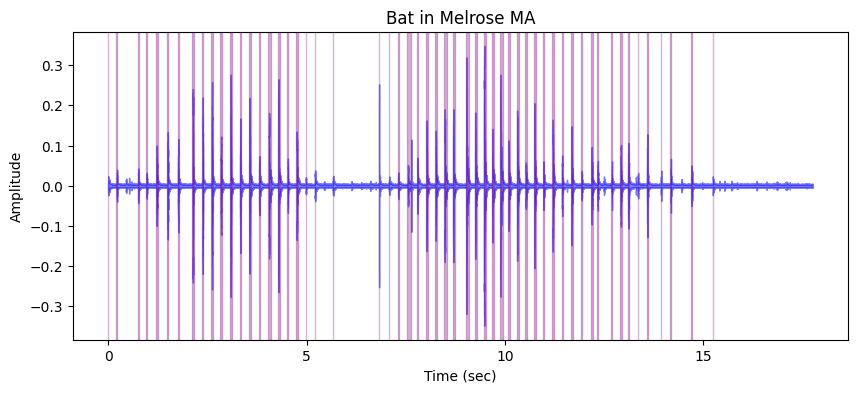

In [91]:
plotWaveform(bat_filtered, 'Bat in Melrose MA', calls)

In [105]:
# Get timestamps for silences between calls
icis = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
icis

[{'start': 0.01, 'end': 0.21},
 {'start': 0.23, 'end': 0.75},
 {'start': 0.77, 'end': 0.96},
 {'start': 0.98, 'end': 1.21},
 {'start': 1.25, 'end': 1.49},
 {'start': 1.52, 'end': 1.75},
 {'start': 1.78, 'end': 2.12},
 {'start': 2.15, 'end': 2.37},
 {'start': 2.4, 'end': 2.6},
 {'start': 2.65, 'end': 2.83},
 {'start': 2.87, 'end': 3.08},
 {'start': 3.13, 'end': 3.31},
 {'start': 3.36, 'end': 3.55},
 {'start': 3.6, 'end': 3.79},
 {'start': 3.83, 'end': 4.04},
 {'start': 4.11, 'end': 4.28},
 {'start': 4.34, 'end': 4.51},
 {'start': 4.54, 'end': 4.74},
 {'start': 4.78, 'end': 4.98},
 {'start': 4.99, 'end': 5.21},
 {'start': 5.22, 'end': 5.67},
 {'start': 5.68, 'end': 6.82},
 {'start': 6.83, 'end': 7.08},
 {'start': 7.09, 'end': 7.3},
 {'start': 7.32, 'end': 7.54},
 {'start': 7.64, 'end': 7.79},
 {'start': 7.81, 'end': 8.02},
 {'start': 8.05, 'end': 8.24},
 {'start': 8.29, 'end': 8.47},
 {'start': 8.53, 'end': 8.69},
 {'start': 8.74, 'end': 9.02},
 {'start': 9.09, 'end': 9.24},
 {'start': 9

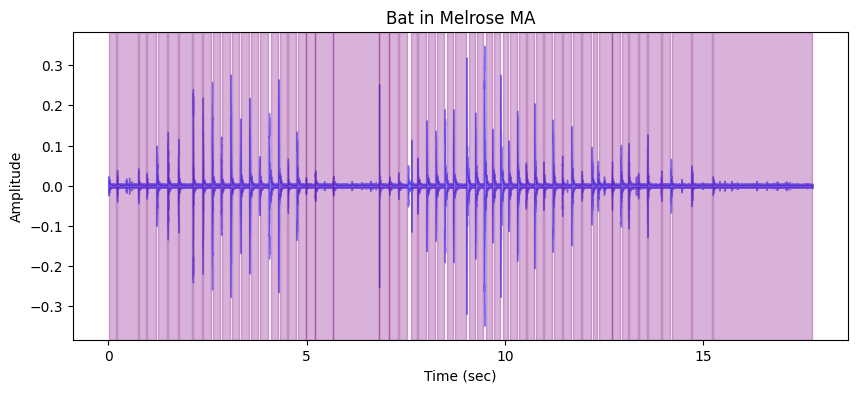

In [93]:
plotWaveform(bat_filtered, 'Bat in Melrose MA', icis)

In [95]:
# Zoom in on a specific section between second 8 and second 9 which looks pretty loud
audio_sections = splitAudioByTimestamps(bat_filtered, [{'start': 8, 'end': 9}], sr)
section = audio_sections[0]

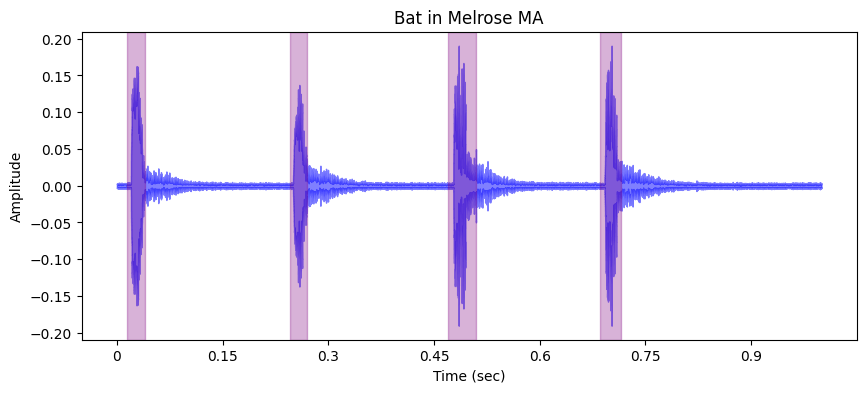

In [96]:
plotWaveform(section, 'Bat in Melrose MA', section_calls)

Attack-decay-sustain-release (ADSR) model of the sound envelope of these bat calls includes a sharp attack, a very steep decay, then a longer sustain and then slow release. The sustain and release have much lower energy, below the VAD threshold of 0.04. For this research, going to only use the higher energy attack/decay portion to estimate call duration. 

In [97]:
# Get timestamps for silences between calls
icis_section = get_timestamps_silences(vad_output=vad_output_section, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
icis_section

[{'start': 0.04, 'end': 0.24},
 {'start': 0.27, 'end': 0.47},
 {'start': 0.51, 'end': 0.69},
 {'start': 0.71, 'end': 0.99}]

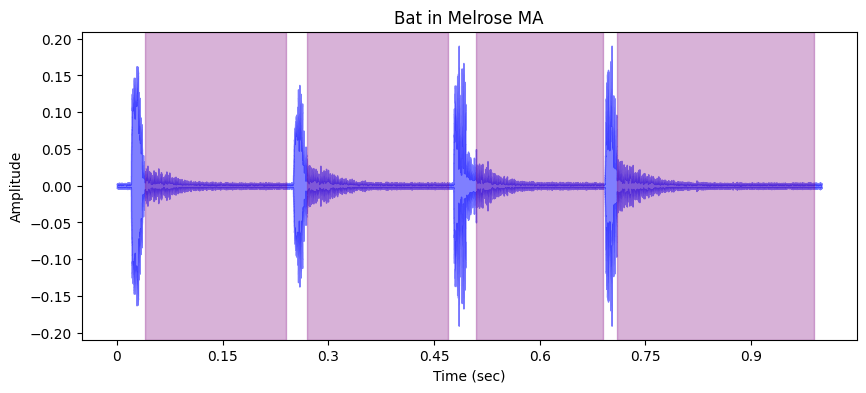

In [98]:
plotWaveform(section, 'Bat in Melrose MA', icis_section)

## Extract time domain data and store in dataframe

In [209]:
# Create pandas data frame with the start/end for each call
# iterate over calls and put all the start times in one list, and all the end times in another list
starts = []
ends = []
durations_ms = []
for call in calls:
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)
start_end_data = {'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)
df.head()

,start,end,duration_ms
0,0.000,0.005,5.0
1,0.210,0.235,25.0
2,0.750,0.770,20.0
3,0.965,0.980,15.0
4,1.210,1.245,35.0


In [211]:
# Add time_to_next_call_ms to the dataframe
time_to_next_call_ms = []
for ici in icis:
    time_to_next_call_ms.append((ici['end'] - ici['start']) * 1000)
df['time_to_next_call_ms'] = time_to_next_call_ms
df.head()

,start,end,duration_ms,time_to_next_call_ms
0,0.000,0.005,5.0,200.0
1,0.210,0.235,25.0,520.0
2,0.750,0.770,20.0,190.0
3,0.965,0.980,15.0,230.0
4,1.210,1.245,35.0,240.0


In [212]:
print(df.shape)

(56, 4)


In [214]:
avg_call_duration = df['duration_ms'].mean()
avg_ici_duration = df['time_to_next_call_ms'].mean()
print(f"Average call duration is {avg_call_duration:.2f} ms")
print(f"Average intercall-interval is {avg_ici_duration:.2f} ms")

Average call duration is 36.88 ms
Average intercall-interval is 279.82 ms


## Extract frequency domain data

In [127]:
# Already computed: stft_bat_filtered_abs
# Already computed: bat_frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH_SPEC)
times = librosa.frames_to_time(np.arange(stft_bat_abs.shape[1]),
                               sr=sr,
                               hop_length=HOP_LENGTH_SPEC)

In [146]:
frequency_data = []
for call in calls:
    energy_cutoff = 0.04
    call_data = extractMinMaxAndMostEnergyFrequencies(
        stft_bat_filtered_abs,
        times,
        call['start'],
        call['end'],
        energy_cutoff)
    frequency_data.append(call_data)

In [147]:
len(frequency_data)

56

In [216]:
# Check the first 2 rows
frequency_data[0:2]

[{'min_freq': np.float64(24375.0),
  'max_freq': np.float64(28687.5),
  'max_energy_freq': np.float64(24750.0)},
 {'min_freq': np.float64(24375.0),
  'max_freq': np.float64(29625.0),
  'max_energy_freq': np.float64(24937.5)}]

In [218]:
# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
df.head()

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq
0,0.000,0.005,5.0,200.0,24375.0,28687.5,24750.0
1,0.210,0.235,25.0,520.0,24375.0,29625.0,24937.5
2,0.750,0.770,20.0,190.0,25125.0,32437.5,26625.0
3,0.965,0.980,15.0,230.0,24375.0,28875.0,25687.5
4,1.210,1.245,35.0,240.0,24750.0,28500.0,25312.5


In [219]:
avg_min_freq = df['min_freq'].mean()
avg_max_freq = df['max_freq'].mean()
avg_freq_of_most_energy = df['max_energy_freq'].mean()
print(f"Average min frequency is {avg_min_freq:.2f} Hz")
print(f"Average max frequency is {avg_max_freq:.2f} Hz")
print(f"Average frequency of most energy is {avg_freq_of_most_energy:.2f} Hz")

Average min frequency is 24850.45 Hz
Average max frequency is 30974.33 Hz
Average frequency of most energy is 26092.63 Hz


## Estimates of slope and shape

### Simple slope
m = (y2 – y1) / (x2 – x1)
where x1 = start_time, y1 = max_freq, x2 = end_time, y2 = min_freq
simple_slope = (min_freq – max_freq) / (end_time - start_time)

In [183]:
# Looking at one of the louder calls in the middle
frequency_data[12]

{'min_freq': np.float64(24562.5),
 'max_freq': np.float64(29437.5),
 'max_energy_freq': np.float64(24937.5)}

In [184]:
calls[12]

{'start': 3.315, 'end': 3.36}

In [190]:
call1_min_freq = frequency_data[12]['min_freq']
call1_max_freq = frequency_data[12]['max_freq']
call1_start_time = calls[12]['start']
call1_end_time = calls[12]['end']

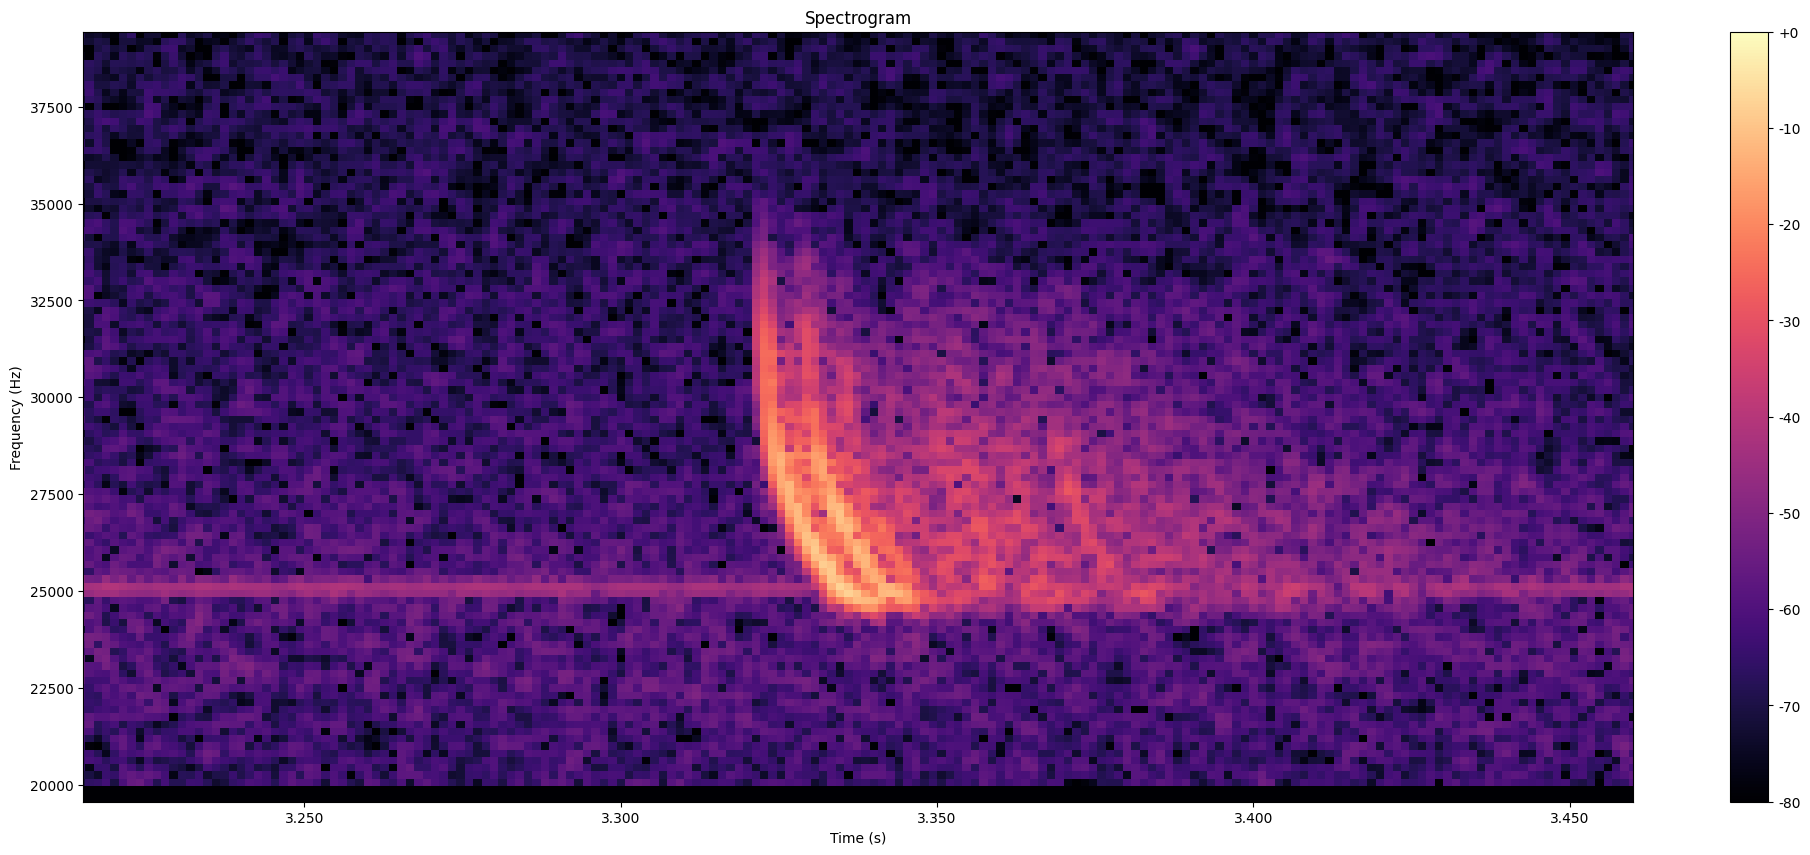

In [194]:
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    call1_min_freq - 5000,
    call1_max_freq + 10000,
    call1_start_time - 0.1,
    call1_end_time + 0.1)

In [201]:
# Calculate a simple slope for the call above
duration_change = call1_min_freq - call1_max_freq
time_change = (call1_end_time - call1_start_time) * 1000 # convert s to ms
simple_slope = duration_change / time_change
print(f'slope of a call: {simple_slope:.2f} Hz/ms')

slope of a call: -108.33 Hz/ms


In [221]:
# Calculate simple slopes for all calls and add to table
df['slope'] = (df['min_freq'] - df['max_freq']) / ((df['end'] - df['start']) * 1000)
df.head()


,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.000,0.005,5.0,200.0,24375.0,28687.5,24750.0,-862.500000
1,0.210,0.235,25.0,520.0,24375.0,29625.0,24937.5,-210.000000
2,0.750,0.770,20.0,190.0,25125.0,32437.5,26625.0,-365.625000
3,0.965,0.980,15.0,230.0,24375.0,28875.0,25687.5,-300.000000
4,1.210,1.245,35.0,240.0,24750.0,28500.0,25312.5,-107.142857


## Data cleaning

In [225]:
df.shape

(56, 8)


In [ ]:
# Drop first and last row, as first and last call may be cut off, and/or have innacurate time_to_next_call

In [226]:
df2 = df.iloc[1:-1]

In [227]:
df2.shape

(54, 8)

In [ ]:
df2

In [288]:
# Look at duration outliers, first create a copy of the original data frame (to preserve original indexing)
df_zscores = df2.copy()
df_zscores.drop(['duration_ms', 'time_to_next_call_ms', 'min_freq', 'max_freq', 'max_energy_freq', 'slope'], axis=1, inplace=True)
df_zscores['duration_ms'] = zscore(df2['duration_ms'])
df_zscores['time_to_next_call_ms'] = zscore(df2['time_to_next_call_ms'])
df_zscores['min_freq'] = zscore(df2['min_freq'])
df_zscores['max_freq'] = zscore(df2['max_freq'])
df_zscores['max_energy_freq'] = zscore(df2['max_energy_freq'])
df_zscores['slope'] = zscore(df2['slope'])
df_zscores

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.210,0.235,-0.719549,1.845077e+00,-0.592280,-0.729123,-1.390568,-0.058455
2,0.750,0.770,-0.997090,-3.294781e-01,0.334767,0.732733,0.626793,-1.306143
3,0.965,0.980,-1.274631,-6.589562e-02,-0.592280,-1.118951,-0.493963,-0.780010
4,1.210,1.245,-0.164468,-1.872866e-16,-0.128757,-1.313865,-0.942266,0.766179
5,1.485,1.520,-0.164468,-6.589562e-02,-0.128757,-1.021494,-0.942266,0.637330
6,1.750,1.785,-0.164468,6.589562e-01,-0.360518,-0.924037,-1.390568,0.551431
7,2.120,2.155,-0.164468,-1.317912e-01,0.334767,0.537819,-0.269812,0.036035
8,2.370,2.400,-0.442009,-2.635825e-01,0.566529,0.635276,0.178491,-0.228822
9,2.600,2.645,0.390613,-3.953737e-01,0.334767,-0.241838,0.178491,0.656419
10,2.830,2.865,-0.164468,-1.976868e-01,-0.128757,-1.021494,-1.166417,0.637330


In [277]:
duration_outliers = df_zscores[abs(df_zscores['duration_ms']) > 3]
duration_outliers.index.tolist()

[25]

In [278]:
time_to_next_call_ms_outliers = df_zscores[abs(df_zscores['time_to_next_call_ms']) > 3]
time_to_next_call_ms_outliers.index.tolist()

[21]

In [279]:
min_freq_outliers = df_zscores[abs(df_zscores['min_freq']) > 3]
min_freq_outliers.index.tolist()

[25]

In [280]:
max_freq_outliers = df_zscores[abs(df_zscores['max_freq']) > 3]
max_freq_outliers.index.tolist()

[]

In [281]:
max_energy_freq_outliers = df_zscores[abs(df_zscores['max_energy_freq']) > 3]
max_energy_freq_outliers.index.tolist()

[]

In [282]:
slope_outliers = df_zscores[abs(df_zscores['slope']) > 3]
slope_outliers.index.tolist()

[19, 24]

Using a z-score above 3 to identify outliers, there's 1 bat call (or other sound) that has an unusual
duration and min-frequency at row 25. There's also 2 bat calls with unusual slopes. Lets examine them more closely

In [285]:
print(df2.iloc[25]['min_freq'])

25500.0


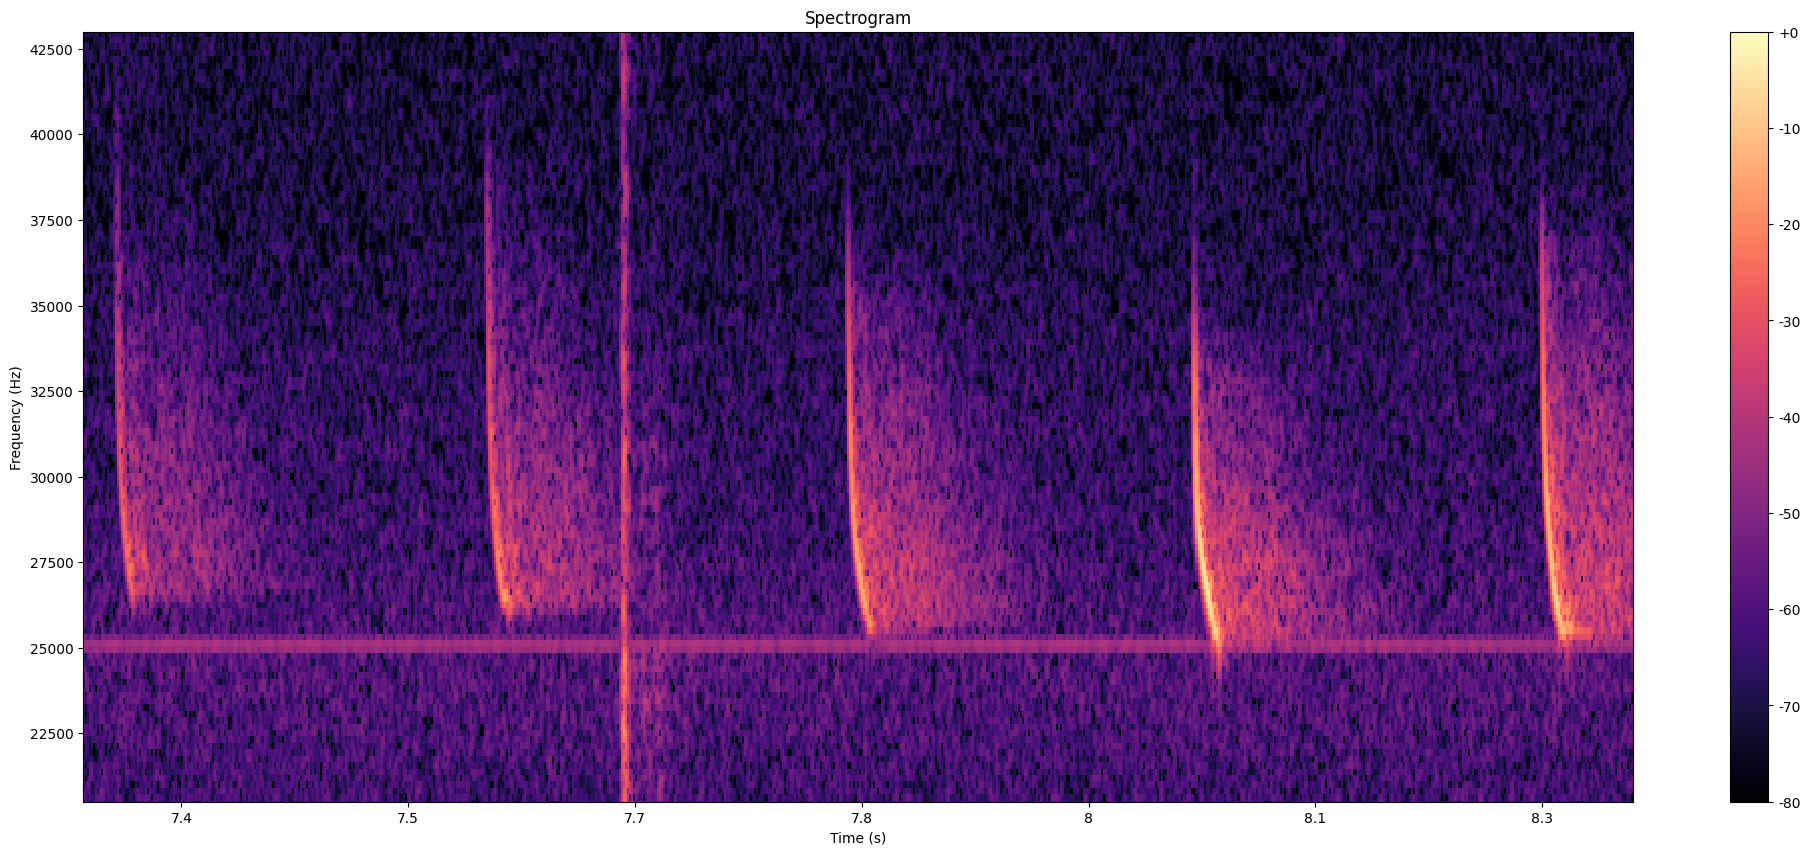

In [286]:
# Looking at call 25 which has unusual duration and min-freq
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    df2.iloc[25]['min_freq'] - 5000,
    df2.iloc[25]['max_freq'] + 10000,
    df2.iloc[25]['start'] - 0.5,
    df2.iloc[25]['end'] + 0.5)

Looks like call 25 is a big noise in the middle of the file which is not a bat call. 
Let's flag this for removal, and possibly remove call 24 as well, whose slope and ICI seem to be messed up
by this noise

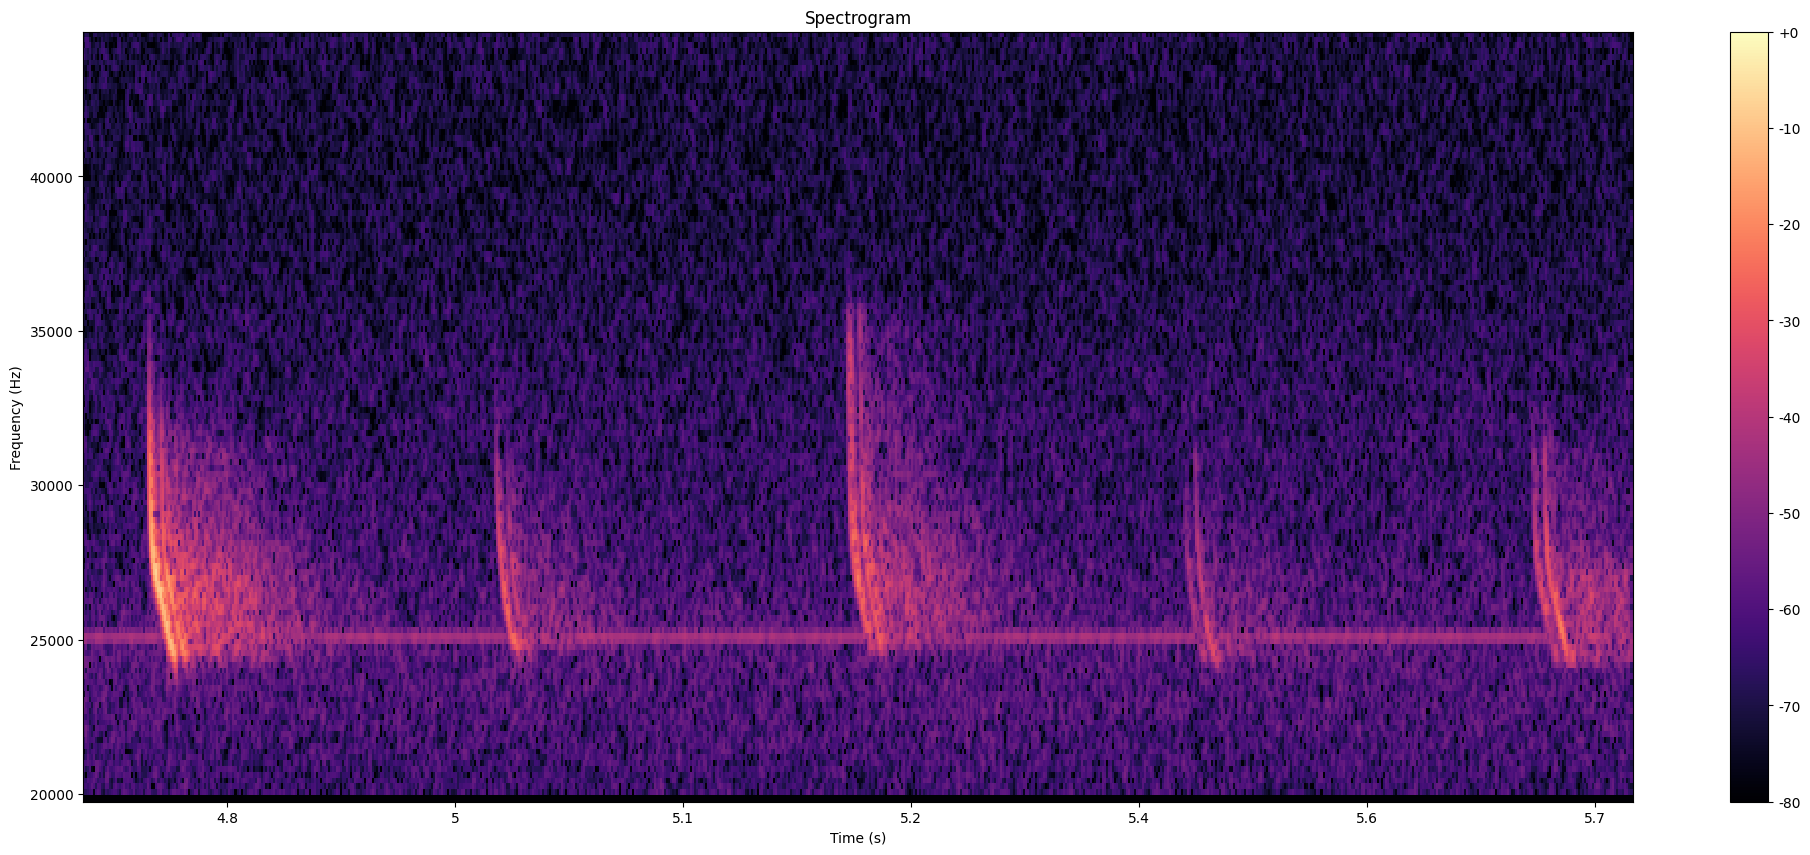

In [287]:
# Looking at call 19 which has an unusual slope
plot_spectrogram_zoom(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    df2.iloc[19]['min_freq'] - 5000,
    df2.iloc[19]['max_freq'] + 10000,
    df2.iloc[19]['start'] - 0.5,
    df2.iloc[19]['end'] + 0.5)

Looks like this call was just quieter than the others (or pointed in another direction) but we can still remove

In [290]:
all_outliers = []
all_outliers.extend(duration_outliers.index.tolist())
all_outliers.extend(min_freq_outliers.index.tolist())
all_outliers.extend(max_freq_outliers.index.tolist())
all_outliers.extend(max_energy_freq_outliers.index.tolist())
all_outliers.extend(slope_outliers.index.tolist())
all_outliers = list(set(all_outliers)) # Keep only unique rows
all_outliers

[24, 25, 19]

In [291]:
# Drop these rows with outliers from the data
df3 = df2.drop(all_outliers)
df3

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.210,0.235,25.0,520.0,24375.0,29625.0,24937.5,-210.000000
2,0.750,0.770,20.0,190.0,25125.0,32437.5,26625.0,-365.625000
3,0.965,0.980,15.0,230.0,24375.0,28875.0,25687.5,-300.000000
4,1.210,1.245,35.0,240.0,24750.0,28500.0,25312.5,-107.142857
5,1.485,1.520,35.0,230.0,24750.0,29062.5,25312.5,-123.214286
6,1.750,1.785,35.0,340.0,24562.5,29250.0,24937.5,-133.928571
7,2.120,2.155,35.0,220.0,25125.0,32062.5,25875.0,-198.214286
8,2.370,2.400,30.0,200.0,25312.5,32250.0,26250.0,-231.250000
9,2.600,2.645,45.0,180.0,25125.0,30562.5,26250.0,-120.833333
10,2.830,2.865,35.0,210.0,24750.0,29062.5,25125.0,-123.214286


In [292]:
# Handling ICI outliers
# Row 21 has an unusually long ICI but is otherwise normal, so maybe the bat took a brief break. Don't need to delete
# this whole call, but maybe remove the ICI so it doesn't throw off the avg
df3.loc[21, 'time_to_next_call_ms'] = np.nan
df3

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.210,0.235,25.0,520.0,24375.0,29625.0,24937.5,-210.000000
2,0.750,0.770,20.0,190.0,25125.0,32437.5,26625.0,-365.625000
3,0.965,0.980,15.0,230.0,24375.0,28875.0,25687.5,-300.000000
4,1.210,1.245,35.0,240.0,24750.0,28500.0,25312.5,-107.142857
5,1.485,1.520,35.0,230.0,24750.0,29062.5,25312.5,-123.214286
6,1.750,1.785,35.0,340.0,24562.5,29250.0,24937.5,-133.928571
7,2.120,2.155,35.0,220.0,25125.0,32062.5,25875.0,-198.214286
8,2.370,2.400,30.0,200.0,25312.5,32250.0,26250.0,-231.250000
9,2.600,2.645,45.0,180.0,25125.0,30562.5,26250.0,-120.833333
10,2.830,2.865,35.0,210.0,24750.0,29062.5,25125.0,-123.214286


In [297]:
# Generate key features from this bat pass and save in a dictionary
avg_duration_ms = df3['duration_ms'].mean()
avg_ici = df3['time_to_next_call_ms'].mean()
avg_min_freq = df3['min_freq'].mean()
avg_max_freq = df3['max_freq'].mean()
avg_freq_of_most_energy = df3['max_energy_freq'].mean()
avg_slope = df3['slope'].mean()

print('Bat pass features:')
print(f'Average call duration: {avg_duration_ms:.2f} ms')
print(f'Average ICI: {avg_ici:.2f} ms')
print(f'Average min frequency: {avg_min_freq / 1000:.2f} kHz')
print(f'Average max frequency: {avg_max_freq/1000:.2f} kHz')
print(f'Average frequency with most energy: {avg_freq_of_most_energy/1000:.2f} kHz')
print(f'Average call slope: {avg_slope:.2f} Hz/ms')

bat_pass_features = {
    'duration_ms': avg_duration_ms,
    'ici': avg_ici,
    'min_freq': avg_min_freq,
    'max_freq': avg_max_freq,
    'avg_freq_of_most_energy': avg_freq_of_most_energy,
    'avg_slope': avg_slope,
}
bat_pass_features

Bat pass features:
Average call duration: 37.84 ms
Average ICI: 224.60 ms
Average min frequency: 24.93 kHz
Average max frequency: 30.96 kHz
Average frequency with most energy: 26.06 kHz
Average call slope: -186.99 Hz/ms


{'duration_ms': np.float64(37.84313725490197),
 'ici': np.float64(224.6),
 'min_freq': np.float64(24930.147058823528),
 'max_freq': np.float64(30959.558823529413),
 'avg_freq_of_most_energy': np.float64(26058.823529411766),
 'avg_slope': np.float64(-186.9859042101693)}